<a href="https://colab.research.google.com/github/andy1680303/machine_learnig_project_2/blob/main/%E6%9C%9F%E6%9C%AB%E5%A0%B1%E5%91%8A_%E4%B9%B3%E7%99%8C_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# 1. Import packages
# =========================

# 基本資料處理
import pandas as pd
import numpy as np

# 視覺化
import matplotlib.pyplot as plt
import seaborn as sns

# 資料切分與前處理
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 模型
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 評估指標
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve, auc

# 讓圖表顯示得比較清楚
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

# 檢查是否成功 import
print("Packages imported successfully!")

Packages imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


匯入資料

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Breast_Cancer.csv')
df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [ ]:
# =========================
# 2. Data overview
# =========================

# 查看資料前五筆
display(df.head())

# 查看資料的行數與列數
print("資料形狀 rows x columns:")
print(df.shape)

print("\n資料共有", df.shape[0], "筆資料")
print("資料共有", df.shape[1], "個欄位")

# 查看所有欄位名稱
print("\n欄位名稱:")
print(df.columns.tolist())

# 查看每個欄位的資料型態與非空值數量
print("\n資料型態與非空值數量:")
df.info()

# 查看每個欄位的缺失值數量
print("\n每個欄位的缺失值數量:")
print(df.isnull().sum())

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


資料形狀 rows x columns:
(4024, 16)

資料共有 4024 筆資料
資料共有 16 個欄位

欄位名稱:
['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status', 'Progesterone Status', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months', 'Status']

資料型態與非空值數量:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object

In [ ]:
df.columns = df.columns.str.strip()

df = df.rename(columns={
    'Reginol Node Positive': 'Regional Node Positive'
})

df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Regional Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [ ]:
print(df['Status'].value_counts())
print(df['Status'].value_counts(normalize=True) * 100)

Status
Alive    3408
Dead      616
Name: count, dtype: int64
Status
Alive    84.691849
Dead     15.308151
Name: proportion, dtype: float64


In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].unique())


Race:
['White' 'Black' 'Other']

Marital Status:
['Married' 'Divorced' 'Single ' 'Widowed' 'Separated']

T Stage:
['T1' 'T2' 'T3' 'T4']

N Stage:
['N1' 'N2' 'N3']

6th Stage:
['IIA' 'IIIA' 'IIIC' 'IIB' 'IIIB']

differentiate:
['Poorly differentiated' 'Moderately differentiated' 'Well differentiated'
 'Undifferentiated']

Grade:
['3' '2' '1' ' anaplastic; Grade IV']

A Stage:
['Regional' 'Distant']

Estrogen Status:
['Positive' 'Negative']

Progesterone Status:
['Positive' 'Negative']

Status:
['Alive' 'Dead']


資料前處理

In [ ]:
# =========================
# Data preprocessing
# =========================

df_processed = df.copy()

# Clean column names
df_processed.columns = df_processed.columns.str.strip()

# Rename typo column
df_processed = df_processed.rename(columns={
    'Reginol Node Positive': 'Regional Node Positive'
})

# Remove possible data leakage column
df_processed = df_processed.drop(columns=['Survival Months'])

# Encode target variable
df_processed['Status'] = df_processed['Status'].map({
    'Alive': 0,
    'Dead': 1
})

# Strip extra spaces in object columns
for col in df_processed.select_dtypes(include='object').columns:
    df_processed[col] = df_processed[col].str.strip()

# Ordinal encoding for ordered clinical variables
df_processed['T Stage'] = df_processed['T Stage'].map({
    'T1': 1,
    'T2': 2,
    'T3': 3,
    'T4': 4
})

df_processed['N Stage'] = df_processed['N Stage'].map({
    'N1': 1,
    'N2': 2,
    'N3': 3
})

df_processed['6th Stage'] = df_processed['6th Stage'].map({
    'IIA': 1,
    'IIB': 2,
    'IIIA': 3,
    'IIIB': 4,
    'IIIC': 5
})

df_processed['differentiate'] = df_processed['differentiate'].map({
    'Well differentiated': 1,
    'Moderately differentiated': 2,
    'Poorly differentiated': 3,
    'Undifferentiated': 4
})

df_processed['Grade'] = df_processed['Grade'].map({
    '1': 1,
    '2': 2,
    '3': 3,
    'anaplastic; Grade IV': 4
})

df_processed['A Stage'] = df_processed['A Stage'].map({
    'Regional': 0,
    'Distant': 1
})

df_processed['Estrogen Status'] = df_processed['Estrogen Status'].map({
    'Negative': 0,
    'Positive': 1
})

df_processed['Progesterone Status'] = df_processed['Progesterone Status'].map({
    'Negative': 0,
    'Positive': 1
})

# One-hot encoding for unordered categorical variables
df_processed = pd.get_dummies(
    df_processed,
    columns=['Race', 'Marital Status'],
    drop_first=True
)

# Check processed data
print(df_processed.shape)
print(df_processed.dtypes)
display(df_processed.head())

# Check if there are any missing values after mapping
print(df_processed.isnull().sum())

(4024, 19)
Age                         int64
T Stage                     int64
N Stage                     int64
6th Stage                   int64
differentiate               int64
Grade                       int64
A Stage                     int64
Tumor Size                  int64
Estrogen Status             int64
Progesterone Status         int64
Regional Node Examined      int64
Regional Node Positive      int64
Status                      int64
Race_Other                   bool
Race_White                   bool
Marital Status_Married       bool
Marital Status_Separated     bool
Marital Status_Single        bool
Marital Status_Widowed       bool
dtype: object


,Age,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Regional Node Positive,Status,Race_Other,Race_White,Marital Status_Married,Marital Status_Separated,Marital Status_Single,Marital Status_Widowed
0,68,1,1,1,3,3,0,4,1,1,24,1,0,False,True,True,False,False,False
1,50,2,2,3,2,2,0,35,1,1,14,5,0,False,True,True,False,False,False
2,58,3,3,5,2,2,0,63,1,1,14,7,0,False,True,False,False,False,False
3,58,1,1,1,3,3,0,18,1,1,2,1,0,False,True,True,False,False,False
4,47,2,1,2,3,3,0,41,1,1,3,1,0,False,True,True,False,False,False


Age                         0
T Stage                     0
N Stage                     0
6th Stage                   0
differentiate               0
Grade                       0
A Stage                     0
Tumor Size                  0
Estrogen Status             0
Progesterone Status         0
Regional Node Examined      0
Regional Node Positive      0
Status                      0
Race_Other                  0
Race_White                  0
Marital Status_Married      0
Marital Status_Separated    0
Marital Status_Single       0
Marital Status_Widowed      0
dtype: int64


資料切分


In [ ]:
# =========================
# Train-test split
# =========================

# Define features and target
X = df_processed.drop(columns=['Status'])
y = df_processed['Status']

# Check target distribution
print("Target distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

Target distribution:
Status
0    3408
1     616
Name: count, dtype: int64
Status
0    84.691849
1    15.308151
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=7890,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining set target distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting set target distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (3219, 18)
X_test shape: (805, 18)
y_train shape: (3219,)
y_test shape: (805,)

Training set target distribution:
Status
0    2726
1     493
Name: count, dtype: int64
Status
0    84.684685
1    15.315315
Name: proportion, dtype: float64

Testing set target distribution:
Status
0    682
1    123
Name: count, dtype: int64
Status
0    84.720497
1    15.279503
Name: proportion, dtype: float64


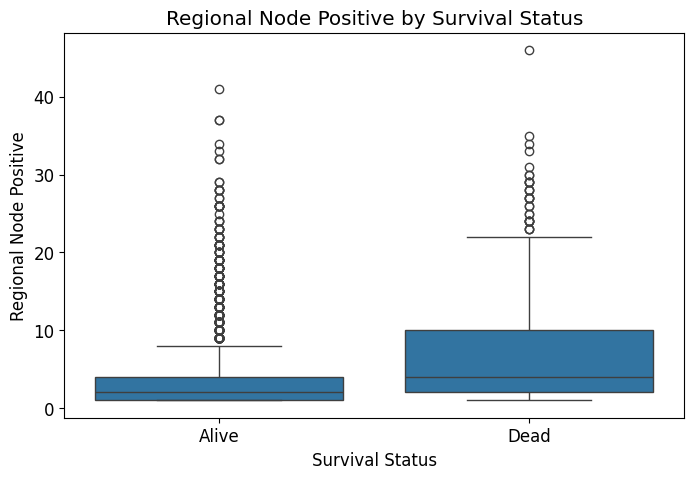

In [ ]:
#EDA圖
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_processed, x='Status', y='Regional Node Positive')
plt.xticks([0, 1], ['Alive', 'Dead'])
plt.title('Regional Node Positive by Survival Status')
plt.xlabel('Survival Status')
plt.ylabel('Regional Node Positive')
plt.show()

標準化

In [ ]:
# =========================
# Feature scaling
# =========================

from sklearn.preprocessing import StandardScaler

# Continuous numerical columns to be standardized
scale_cols = [
    'Age',
    'Tumor Size',
    'Regional Node Examined',
    'Regional Node Positive'
]

# Make copies to avoid modifying original X_train and X_test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler only on training data, then transform both training and testing data
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

# Check scaled data
display(X_train_scaled.head())

,Age,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Regional Node Positive,Race_Other,Race_White,Marital Status_Married,Marital Status_Separated,Marital Status_Single,Marital Status_Widowed
871,-0.106828,2,1,2,2,2,0,-0.025076,1,1,-1.400284,-0.609217,False,True,True,False,False,False
3836,0.339623,2,3,5,3,3,0,-0.261101,1,0,0.195992,1.536801,False,True,True,False,False,False
1732,-0.999731,1,1,1,2,2,0,-0.638740,1,1,-1.031913,-0.609217,True,False,True,False,False,False
1535,1.009300,2,1,2,2,2,0,-0.449920,1,1,-1.523075,-0.414125,False,True,False,False,True,False
110,0.786075,1,2,3,2,2,0,-0.780355,1,1,0.073201,-0.023940,False,True,True,False,False,False


In [ ]:
# Check mean and standard deviation after scaling
print("Mean of scaled training features:")
print(X_train_scaled[scale_cols].mean())

print("\nStandard deviation of scaled training features:")
print(X_train_scaled[scale_cols].std())

Mean of scaled training features:
Age                      -3.101313e-16
Tumor Size                1.324404e-17
Regional Node Examined    1.103670e-16
Regional Node Positive    2.041789e-17
dtype: float64

Standard deviation of scaled training features:
Age                       1.000155
Tumor Size                1.000155
Regional Node Examined    1.000155
Regional Node Positive    1.000155
dtype: float64


建模型 Logistic Regression(有/無balance)

In [ ]:
# =========================
# Model 1A - Logistic Regression without class balance
# =========================

log_reg_no_balance = LogisticRegression(
    max_iter=5000,
    random_state=7890
)

# Train the model
log_reg_no_balance.fit(X_train_scaled, y_train)

# Make predictions
y_pred_log_no_balance = log_reg_no_balance.predict(X_test_scaled)

# Predict probabilities for ROC-AUC
y_prob_log_no_balance = log_reg_no_balance.predict_proba(X_test_scaled)[:, 1]

# Evaluate model performance
accuracy_log_no_balance = accuracy_score(y_test, y_pred_log_no_balance)
precision_log_no_balance = precision_score(y_test, y_pred_log_no_balance, zero_division=0)
recall_log_no_balance = recall_score(y_test, y_pred_log_no_balance)
f1_log_no_balance = f1_score(y_test, y_pred_log_no_balance)
roc_auc_log_no_balance = roc_auc_score(y_test, y_prob_log_no_balance)

print("Logistic Regression without Class Balance")
print("------------------------------------------")
print("Accuracy:", round(accuracy_log_no_balance, 4))
print("Precision:", round(precision_log_no_balance, 4))
print("Recall:", round(recall_log_no_balance, 4))
print("F1-score:", round(f1_log_no_balance, 4))
print("ROC-AUC:", round(roc_auc_log_no_balance, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_no_balance, zero_division=0))

Logistic Regression without Class Balance
------------------------------------------
Accuracy: 0.8658
Precision: 0.7586
Recall: 0.1789
F1-score: 0.2895
ROC-AUC: 0.7898

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       682
           1       0.76      0.18      0.29       123

    accuracy                           0.87       805
   macro avg       0.81      0.58      0.61       805
weighted avg       0.85      0.87      0.83       805



In [ ]:
# =========================
# Model 1B - Logistic Regression with class balance
# =========================

log_reg_balanced = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    random_state=7890
)

# Train the model
log_reg_balanced.fit(X_train_scaled, y_train)

# Make predictions
y_pred_log_balanced = log_reg_balanced.predict(X_test_scaled)

# Predict probabilities for ROC-AUC
y_prob_log_balanced = log_reg_balanced.predict_proba(X_test_scaled)[:, 1]

# Evaluate model performance
accuracy_log_balanced = accuracy_score(y_test, y_pred_log_balanced)
precision_log_balanced = precision_score(y_test, y_pred_log_balanced, zero_division=0)
recall_log_balanced = recall_score(y_test, y_pred_log_balanced)
f1_log_balanced = f1_score(y_test, y_pred_log_balanced)
roc_auc_log_balanced = roc_auc_score(y_test, y_prob_log_balanced)

print("Logistic Regression with Class Balance")
print("---------------------------------------")
print("Accuracy:", round(accuracy_log_balanced, 4))
print("Precision:", round(precision_log_balanced, 4))
print("Recall:", round(recall_log_balanced, 4))
print("F1-score:", round(f1_log_balanced, 4))
print("ROC-AUC:", round(roc_auc_log_balanced, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_balanced, zero_division=0))

Logistic Regression with Class Balance
---------------------------------------
Accuracy: 0.7155
Precision: 0.308
Recall: 0.6911
F1-score: 0.4261
ROC-AUC: 0.795

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.72      0.81       682
           1       0.31      0.69      0.43       123

    accuracy                           0.72       805
   macro avg       0.62      0.71      0.62       805
weighted avg       0.83      0.72      0.75       805



In [ ]:
# =========================
# Compare Logistic Regression Models
# =========================

logistic_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression + Class Balance"
    ],
    "Accuracy": [
        accuracy_log_no_balance,
        accuracy_log_balanced
    ],
    "Precision": [
        precision_log_no_balance,
        precision_log_balanced
    ],
    "Recall": [
        recall_log_no_balance,
        recall_log_balanced
    ],
    "F1-score": [
        f1_log_no_balance,
        f1_log_balanced
    ],
    "ROC-AUC": [
        roc_auc_log_no_balance,
        roc_auc_log_balanced
    ]
})

logistic_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.865839,0.758621,0.178862,0.289474,0.789834
1,Logistic Regression + Class Balance,0.715528,0.307971,0.691057,0.426065,0.795043


建模型 SVM(有/無balance)

In [ ]:
# =========================
# Model 2A - SVM without class balance
# =========================

svm_no_balance = SVC(
    kernel='rbf',
    probability=True,
    random_state=7890
)

# Train the model
svm_no_balance.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm_no_balance = svm_no_balance.predict(X_test_scaled)

# Predict probabilities for ROC-AUC
y_prob_svm_no_balance = svm_no_balance.predict_proba(X_test_scaled)[:, 1]

# Evaluate model performance
accuracy_svm_no_balance = accuracy_score(y_test, y_pred_svm_no_balance)
precision_svm_no_balance = precision_score(y_test, y_pred_svm_no_balance, zero_division=0)
recall_svm_no_balance = recall_score(y_test, y_pred_svm_no_balance)
f1_svm_no_balance = f1_score(y_test, y_pred_svm_no_balance)
roc_auc_svm_no_balance = roc_auc_score(y_test, y_prob_svm_no_balance)

print("SVM without Class Balance")
print("-------------------------")
print("Accuracy:", round(accuracy_svm_no_balance, 4))
print("Precision:", round(precision_svm_no_balance, 4))
print("Recall:", round(recall_svm_no_balance, 4))
print("F1-score:", round(f1_svm_no_balance, 4))
print("ROC-AUC:", round(roc_auc_svm_no_balance, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_no_balance, zero_division=0))

SVM without Class Balance
-------------------------
Accuracy: 0.8522
Precision: 0.8333
Recall: 0.0407
F1-score: 0.0775
ROC-AUC: 0.6526

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       682
           1       0.83      0.04      0.08       123

    accuracy                           0.85       805
   macro avg       0.84      0.52      0.50       805
weighted avg       0.85      0.85      0.79       805



In [ ]:
# =========================
# Model 2B - SVM with class balance
# =========================

svm_balanced = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=7890
)

# Train the model
svm_balanced.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm_balanced = svm_balanced.predict(X_test_scaled)

# Predict probabilities for ROC-AUC
y_prob_svm_balanced = svm_balanced.predict_proba(X_test_scaled)[:, 1]

# Evaluate model performance
accuracy_svm_balanced = accuracy_score(y_test, y_pred_svm_balanced)
precision_svm_balanced = precision_score(y_test, y_pred_svm_balanced, zero_division=0)
recall_svm_balanced = recall_score(y_test, y_pred_svm_balanced)
f1_svm_balanced = f1_score(y_test, y_pred_svm_balanced)
roc_auc_svm_balanced = roc_auc_score(y_test, y_prob_svm_balanced)

print("SVM with Class Balance")
print("----------------------")
print("Accuracy:", round(accuracy_svm_balanced, 4))
print("Precision:", round(precision_svm_balanced, 4))
print("Recall:", round(recall_svm_balanced, 4))
print("F1-score:", round(f1_svm_balanced, 4))
print("ROC-AUC:", round(roc_auc_svm_balanced, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_balanced, zero_division=0))

SVM with Class Balance
----------------------
Accuracy: 0.7267
Precision: 0.3197
Recall: 0.6992
F1-score: 0.4388
ROC-AUC: 0.7925

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.73      0.82       682
           1       0.32      0.70      0.44       123

    accuracy                           0.73       805
   macro avg       0.63      0.72      0.63       805
weighted avg       0.84      0.73      0.76       805



In [ ]:
建模型 random forest(有/無balance)

In [ ]:
# =========================
# Model 3A - Random Forest without class balance
# =========================

rf_no_balance = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=7890
)

# Train the model
rf_no_balance.fit(X_train, y_train)

# Make predictions
y_pred_rf_no_balance = rf_no_balance.predict(X_test)

# Predict probabilities for ROC-AUC
y_prob_rf_no_balance = rf_no_balance.predict_proba(X_test)[:, 1]

# Evaluate model performance
accuracy_rf_no_balance = accuracy_score(y_test, y_pred_rf_no_balance)
precision_rf_no_balance = precision_score(y_test, y_pred_rf_no_balance, zero_division=0)
recall_rf_no_balance = recall_score(y_test, y_pred_rf_no_balance)
f1_rf_no_balance = f1_score(y_test, y_pred_rf_no_balance)
roc_auc_rf_no_balance = roc_auc_score(y_test, y_prob_rf_no_balance)

print("Random Forest without Class Balance")
print("-----------------------------------")
print("Accuracy:", round(accuracy_rf_no_balance, 4))
print("Precision:", round(precision_rf_no_balance, 4))
print("Recall:", round(recall_rf_no_balance, 4))
print("F1-score:", round(f1_rf_no_balance, 4))
print("ROC-AUC:", round(roc_auc_rf_no_balance, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_no_balance, zero_division=0))

Random Forest without Class Balance
-----------------------------------
Accuracy: 0.8596
Precision: 0.75
Recall: 0.122
F1-score: 0.2098
ROC-AUC: 0.7879

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       682
           1       0.75      0.12      0.21       123

    accuracy                           0.86       805
   macro avg       0.81      0.56      0.57       805
weighted avg       0.85      0.86      0.81       805



In [ ]:
# =========================
# Model 3B - Random Forest with class balance
# =========================

rf_balanced = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=7890
)

# Train the model
rf_balanced.fit(X_train, y_train)

# Make predictions
y_pred_rf_balanced = rf_balanced.predict(X_test)

# Predict probabilities for ROC-AUC
y_prob_rf_balanced = rf_balanced.predict_proba(X_test)[:, 1]

# Evaluate model performance
accuracy_rf_balanced = accuracy_score(y_test, y_pred_rf_balanced)
precision_rf_balanced = precision_score(y_test, y_pred_rf_balanced, zero_division=0)
recall_rf_balanced = recall_score(y_test, y_pred_rf_balanced)
f1_rf_balanced = f1_score(y_test, y_pred_rf_balanced)
roc_auc_rf_balanced = roc_auc_score(y_test, y_prob_rf_balanced)

print("Random Forest with Class Balance")
print("--------------------------------")
print("Accuracy:", round(accuracy_rf_balanced, 4))
print("Precision:", round(precision_rf_balanced, 4))
print("Recall:", round(recall_rf_balanced, 4))
print("F1-score:", round(f1_rf_balanced, 4))
print("ROC-AUC:", round(roc_auc_rf_balanced, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_balanced, zero_division=0))

Random Forest with Class Balance
--------------------------------
Accuracy: 0.8
Precision: 0.3782
Recall: 0.4797
F1-score: 0.4229
ROC-AUC: 0.7611

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       682
           1       0.38      0.48      0.42       123

    accuracy                           0.80       805
   macro avg       0.64      0.67      0.65       805
weighted avg       0.82      0.80      0.81       805



In [ ]:
# =========================
# Model comparison summary
# =========================

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression + Class Balance",
        "SVM",
        "SVM + Class Balance",
        "Random Forest",
        "Random Forest + Class Balance"
    ],
    "Accuracy": [
        accuracy_log_no_balance,
        accuracy_log_balanced,
        accuracy_svm_no_balance,
        accuracy_svm_balanced,
        accuracy_rf_no_balance,
        accuracy_rf_balanced
    ],
    "Precision": [
        precision_log_no_balance,
        precision_log_balanced,
        precision_svm_no_balance,
        precision_svm_balanced,
        precision_rf_no_balance,
        precision_rf_balanced
    ],
    "Recall": [
        recall_log_no_balance,
        recall_log_balanced,
        recall_svm_no_balance,
        recall_svm_balanced,
        recall_rf_no_balance,
        recall_rf_balanced
    ],
    "F1-score": [
        f1_log_no_balance,
        f1_log_balanced,
        f1_svm_no_balance,
        f1_svm_balanced,
        f1_rf_no_balance,
        f1_rf_balanced
    ],
    "ROC-AUC": [
        roc_auc_log_no_balance,
        roc_auc_log_balanced,
        roc_auc_svm_no_balance,
        roc_auc_svm_balanced,
        roc_auc_rf_no_balance,
        roc_auc_rf_balanced
    ]
})

model_results.sort_values(by="F1-score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,SVM + Class Balance,0.726708,0.319703,0.699187,0.438776,0.792456
1,Logistic Regression + Class Balance,0.715528,0.307971,0.691057,0.426065,0.795043
5,Random Forest + Class Balance,0.800000,0.378205,0.479675,0.422939,0.761057
0,Logistic Regression,0.865839,0.758621,0.178862,0.289474,0.789834
4,Random Forest,0.859627,0.750000,0.121951,0.209790,0.787855
2,SVM,0.852174,0.833333,0.040650,0.077519,0.652576


final model:SVM + Class Balanceu.優化模型

In [ ]:
# =========================
# Hyperparameter tuning for SVM using GridSearchCV
# =========================

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf']
}

# Build base SVM model
svm_base = SVC(
    class_weight='balanced',
    probability=True,
    random_state=7890
)

# Grid search with cross-validation
grid_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# Fit grid search on training data
grid_svm.fit(X_train_scaled, y_train)

# Show best parameters and best CV score
print("Best parameters:")
print(grid_svm.best_params_)

print("\nBest cross-validation F1-score:")
print(grid_svm.best_score_)

Best parameters:
{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}

Best cross-validation F1-score:
0.40189225156453573


In [ ]:
# =========================
# Evaluate best SVM model on test set
# =========================

best_svm = grid_svm.best_estimator_

# Make predictions
y_pred_best_svm = best_svm.predict(X_test_scaled)

# Predict probabilities for ROC-AUC
y_prob_best_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

# Evaluate performance
accuracy_best_svm = accuracy_score(y_test, y_pred_best_svm)
precision_best_svm = precision_score(y_test, y_pred_best_svm, zero_division=0)
recall_best_svm = recall_score(y_test, y_pred_best_svm)
f1_best_svm = f1_score(y_test, y_pred_best_svm)
roc_auc_best_svm = roc_auc_score(y_test, y_prob_best_svm)

print("Best SVM Performance on Test Set")
print("--------------------------------")
print("Accuracy:", round(accuracy_best_svm, 4))
print("Precision:", round(precision_best_svm, 4))
print("Recall:", round(recall_best_svm, 4))
print("F1-score:", round(f1_best_svm, 4))
print("ROC-AUC:", round(roc_auc_best_svm, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_svm, zero_division=0))

Best SVM Performance on Test Set
--------------------------------
Accuracy: 0.7329
Precision: 0.3189
Recall: 0.6585
F1-score: 0.4297
ROC-AUC: 0.8035

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.75      0.83       682
           1       0.32      0.66      0.43       123

    accuracy                           0.73       805
   macro avg       0.62      0.70      0.63       805
weighted avg       0.83      0.73      0.77       805



In [ ]:
# Show grid search results
grid_results = pd.DataFrame(grid_svm.cv_results_)

grid_results = grid_results[
    ['param_C', 'param_gamma', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values(by='rank_test_score')

grid_results.head(10)

,param_C,param_gamma,mean_test_score,std_test_score,rank_test_score
5,1.0,0.01,0.401892,0.021903,1
4,1.0,scale,0.393905,0.016945,2
9,10.0,0.01,0.389210,0.022027,3
6,1.0,0.1,0.385253,0.015509,4
13,100.0,0.01,0.382681,0.016133,5
0,0.1,scale,0.378924,0.024108,6
1,0.1,0.01,0.377322,0.018518,7
8,10.0,scale,0.375705,0.021508,8
2,0.1,0.1,0.375682,0.014790,9
10,10.0,0.1,0.324389,0.012706,10


In [ ]:
# =========================
# Compare original SVM and tuned SVM
# =========================

svm_tuning_comparison = pd.DataFrame({
    "Model": [
        "SVM + Class Balance",
        "Tuned SVM + Class Balance"
    ],
    "Accuracy": [
        accuracy_svm_balanced,
        accuracy_best_svm
    ],
    "Precision": [
        precision_svm_balanced,
        precision_best_svm
    ],
    "Recall": [
        recall_svm_balanced,
        recall_best_svm
    ],
    "F1-score": [
        f1_svm_balanced,
        f1_best_svm
    ],
    "ROC-AUC": [
        roc_auc_svm_balanced,
        roc_auc_best_svm
    ]
})

svm_tuning_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,SVM + Class Balance,0.726708,0.319703,0.699187,0.438776,0.792456
1,Tuned SVM + Class Balance,0.732919,0.318898,0.658537,0.429708,0.803519


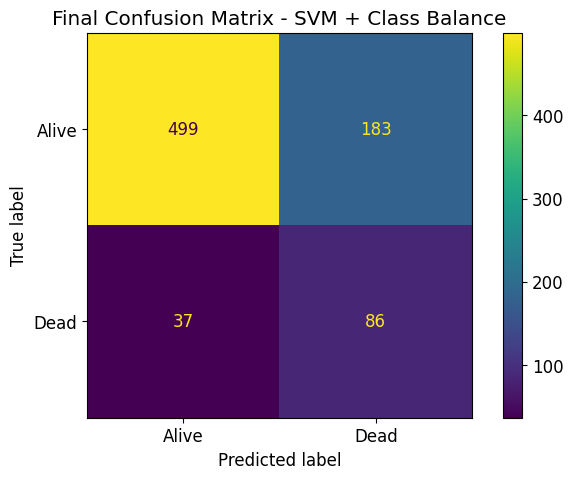

In [ ]:
# =========================
# Final Confusion Matrix - SVM + Class Balance
# =========================

cm_final = confusion_matrix(y_test, y_pred_svm_balanced)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=['Alive', 'Dead']
)

disp.plot()
plt.title("Final Confusion Matrix - SVM + Class Balance")
plt.show()

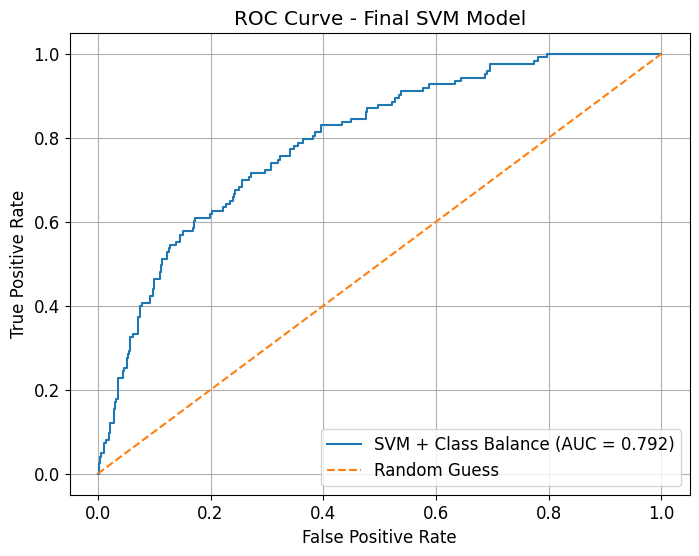

In [ ]:
# =========================
# ROC Curve - SVM + Class Balance
# =========================

fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_prob_svm_balanced)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f"SVM + Class Balance (AUC = {roc_auc_svm:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final SVM Model")
plt.legend()
plt.grid(True)
plt.show()

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 362, in run
    resolver = self.make_resolver(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 177, in make_resolver
    return pip._internal.resolution.resolvelib.resolver.Resolver(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 58, in __init__
    self.factory = Factory(
                  

PermutationExplainer explainer: 201it [14:51,  4.46s/it]


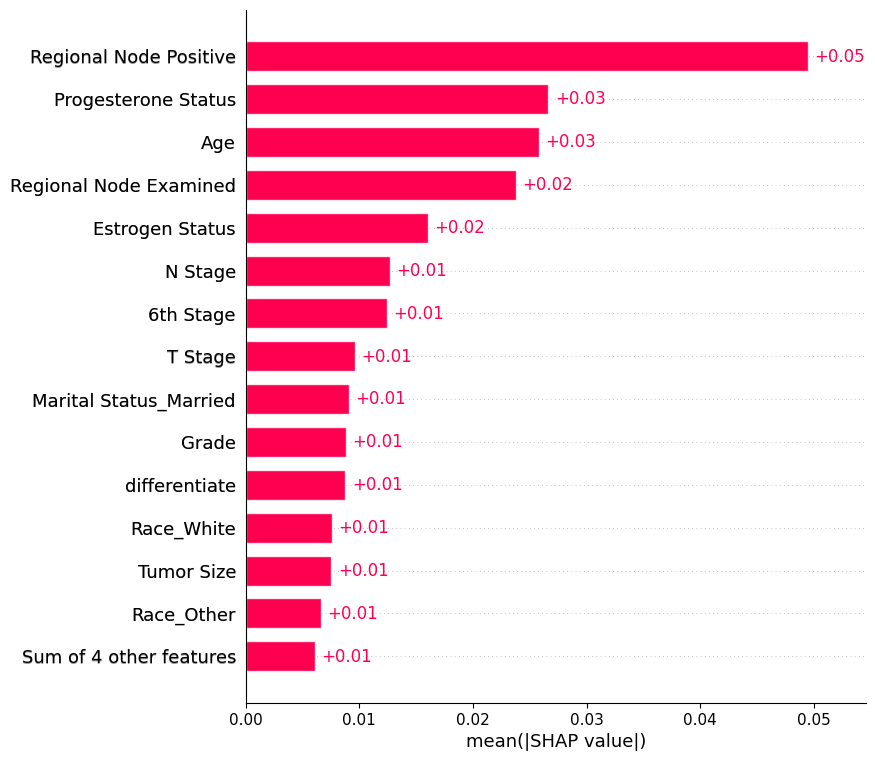

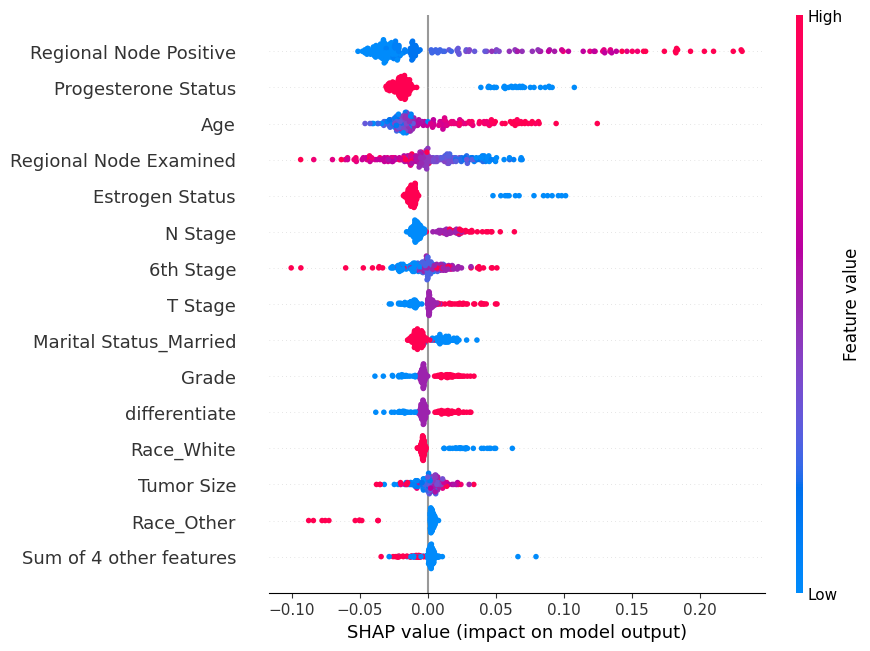

In [ ]:
# =========================
# SHAP Analysis for Final SVM Model
# =========================

import shap

# Convert data to float
X_train_shap = X_train_scaled.astype(float)
X_test_shap = X_test_scaled.astype(float)

# Sample background and test data to reduce computation time
background = shap.sample(X_train_shap, 100, random_state=7890)
X_test_sample = shap.sample(X_test_shap, 200, random_state=7890)

# Build SHAP explainer using SVM predicted probabilities
explainer = shap.Explainer(
    svm_balanced.predict_proba,
    background
)

# Calculate SHAP values
shap_values = explainer(X_test_sample)

# Extract SHAP values for Dead class
shap_values_dead = shap.Explanation(
    values=shap_values.values[:, :, 1],
    base_values=shap_values.base_values[:, 1],
    data=X_test_sample.values,
    feature_names=X_test_sample.columns
)

# SHAP bar plot
shap.plots.bar(shap_values_dead, max_display=15)

# SHAP beeswarm plot
shap.plots.beeswarm(shap_values_dead, max_display=15)

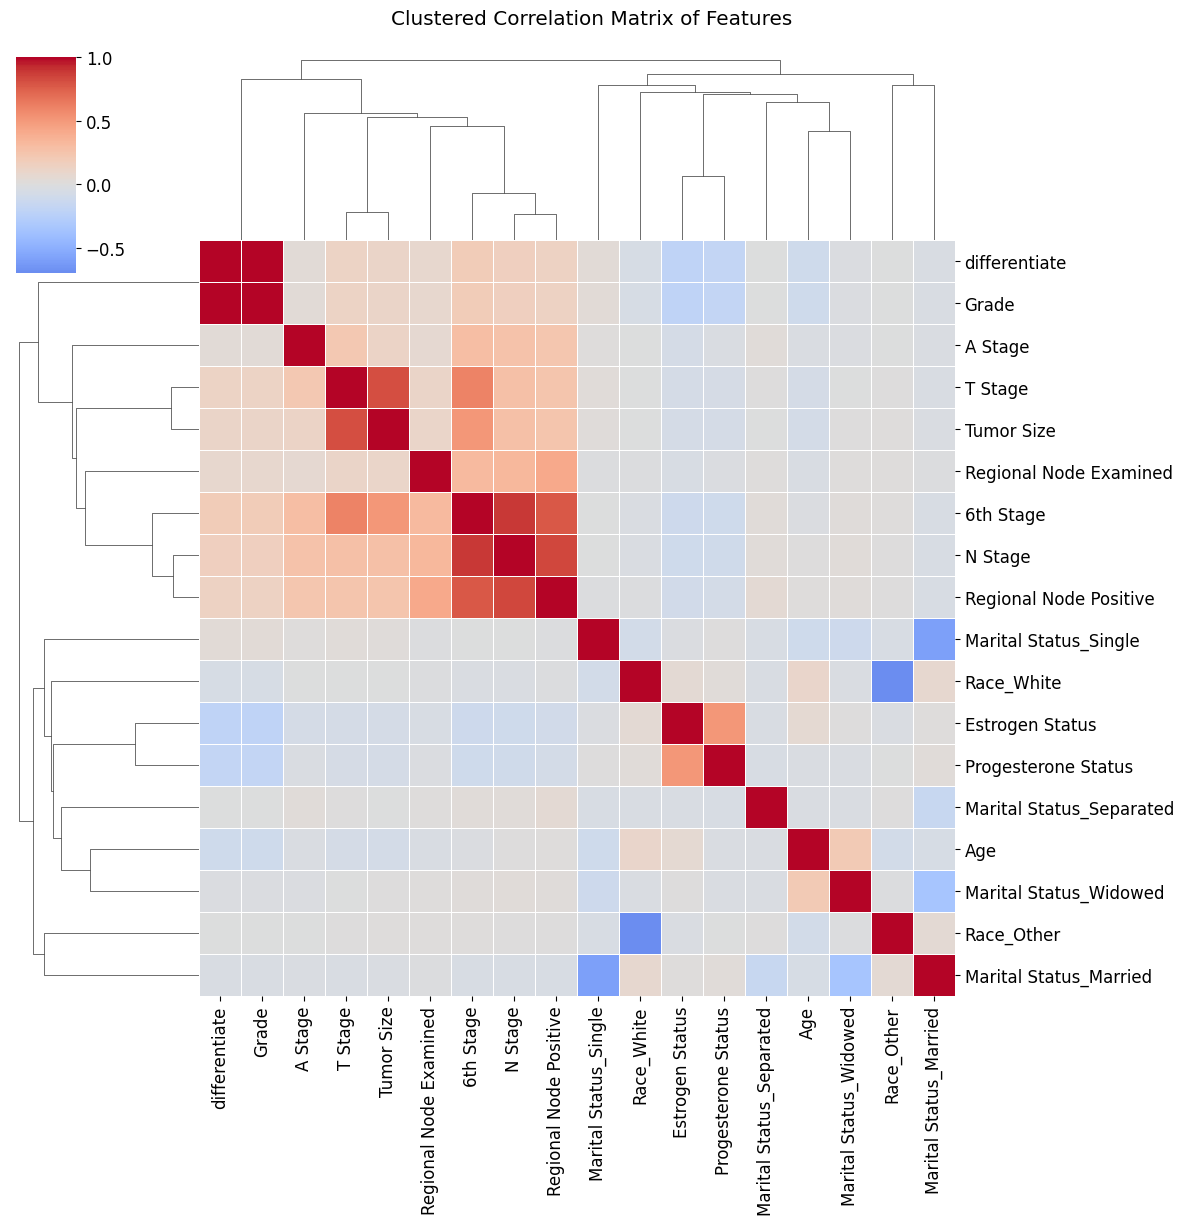

In [ ]:
# =========================
# Correlation clustermap
# =========================
# Use features only
X_corr = df_processed.drop(columns=['Status'])

# Make sure all columns are numeric
X_corr = X_corr.astype(float)

# Calculate correlation matrix
corr_matrix = X_corr.corr()
sns.clustermap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    figsize=(12, 12),
    linewidths=0.5
)

plt.suptitle("Clustered Correlation Matrix of Features", y=1.02)
plt.show()

In [ ]:
# =========================
# Find highly correlated feature pairs
# =========================

corr_abs = X_corr.corr().abs()

upper_triangle = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

# Show pairs with correlation higher than 0.7
high_corr_pairs = high_corr_pairs[
    high_corr_pairs["Correlation"] > 0.7
].sort_values(by="Correlation", ascending=False)

high_corr_pairs

,Feature 1,Feature 2,Correlation
62,differentiate,Grade,1.000000
33,N Stage,6th Stage,0.881880
41,N Stage,Regional Node Positive,0.838073
22,T Stage,Tumor Size,0.809176
55,6th Stage,Regional Node Positive,0.773963
